In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)


df = pd.read_csv("student_performance.csv")
df.head()

# df.groupby("result")[["study_hours","attendance","assignments"]].mean()
print("Available columns in df:", df.columns.tolist())

Environment ready!
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
Available columns in df: ['StudentID', 'G1', 'G2', 'G3', 'Mjob', 'Fjob', 'age', 'address', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:
df.head()

,StudentID,G1,G2,G3,Mjob,Fjob,age,address,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,1,6,2,2,teacher,at_home,21,rural,3,1,no,yes,yes,yes,yes,yes,no,yes
1,2,19,11,18,health,teacher,18,rural,1,1,no,no,no,no,yes,no,no,no
2,3,14,7,19,health,other,20,urban,1,1,yes,yes,yes,no,no,no,yes,yes
3,4,10,2,6,services,health,21,urban,3,1,yes,no,yes,no,yes,no,no,no
4,5,7,0,19,health,health,18,rural,4,1,no,no,yes,no,yes,yes,yes,no


In [ ]:
df.tail()

,StudentID,G1,G2,G3,Mjob,Fjob,age,address,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
95,96,11,15,0,other,other,15,rural,3,0,yes,yes,yes,no,yes,no,no,no
96,97,1,2,19,at_home,teacher,21,rural,3,2,no,yes,yes,no,no,no,yes,yes
97,98,0,19,0,health,services,15,rural,2,0,yes,no,yes,no,no,yes,no,yes
98,99,15,3,2,health,at_home,17,rural,4,1,yes,no,yes,yes,no,yes,yes,no
99,100,4,18,17,other,teacher,19,rural,4,2,yes,yes,yes,yes,no,no,yes,yes


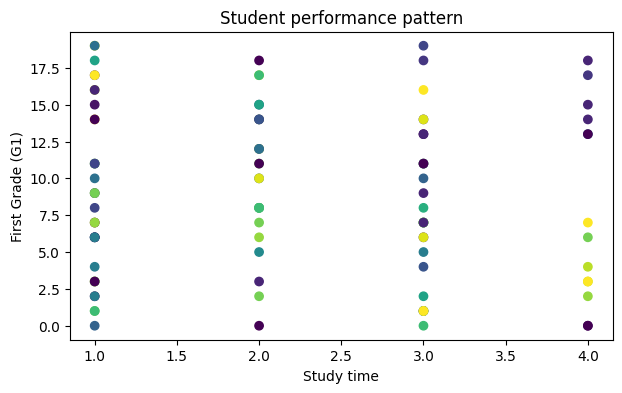

X shape: (100, 3)
y shape: (100,)
Training rows: 80
Testing rows : 20
Model trained!


In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(df["studytime"], df["G1"], c=df["G3"])
plt.xlabel("Study time")
plt.ylabel("First Grade (G1)")
plt.title("Student performance pattern")
plt.show()

X = df[["studytime", "G1", "G2"]]
# Convert G3 to a categorical target for classification
y = (df["G3"] >= 10).astype(int) # 1 for Pass, 0 for Fail

print("X shape:", X.shape)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Make pridiction

In [ ]:
prediction=model.predict(X_test)
print("predictions:")
print(prediction)
print("X_test:")
print(X_test)
accuracy=accuracy_score(y_test,prediction)
print("Accuracy:", accuracy)


predictions:
[1 0 0 1 0 0 0 0 1 0 1 1 0 0 1 1 1 1 0 1]
X_test:
    studytime  G1  G2
36          1  17   5
18          3  11  12
71          2  12  16
60          4   3  16
11          1   2   4
26          3  19  12
39          1  19  19
43          1   7   0
33          1  17   1
41          1   6   6
78          4   0   1
2           1  14   7
98          4  15   3
95          3  11  15
16          1   0  14
31          2   8   6
17          2  11   9
53          3   5   0
73          3  14   1
77          2   8  18
Accuracy: 0.65


Accuracy

In [ ]:
accuracy=accuracy_score(y_test,prediction)
print(f"test accuracy: {accuracy:.2%}")


test accuracy: 65.00%


decision tree

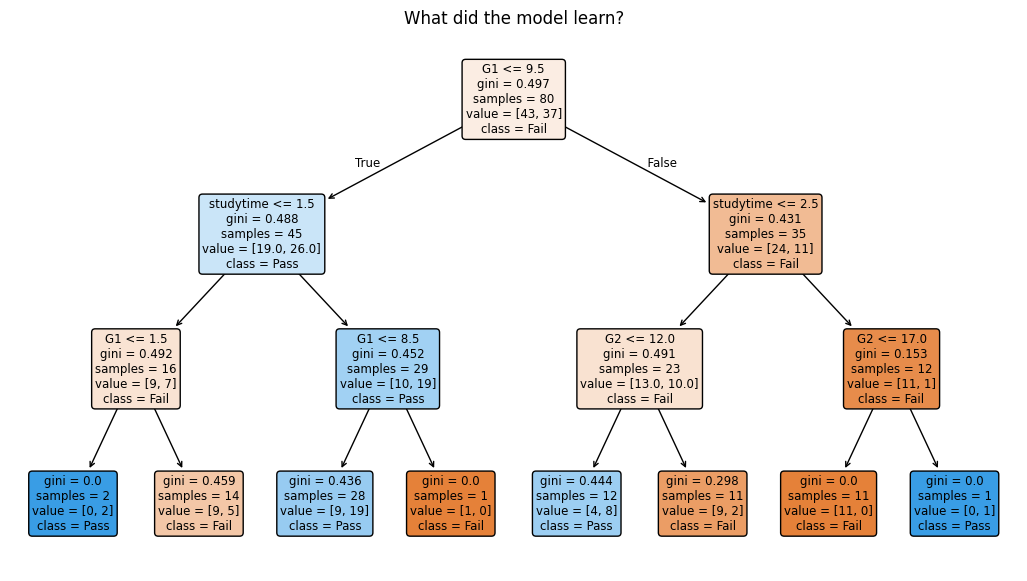

In [ ]:
plt.figure(figsize=(13,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True
)
plt.title("What did the model learn?")
plt.show()